In [18]:
# importuri

import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt

In [4]:
# Verifică dacă CUDA (suportul pentru plăci video NVIDIA) este disponibil
gpu_disponibil = torch.cuda.is_available()
print(f"GPU disponibil pentru antrenare: {gpu_disponibil}")

if gpu_disponibil:
    # Afișează numărul de plăci video și numele acestora
    nr_gpu = torch.cuda.device_count()
    print(f"Număr GPU-uri detectate: {nr_gpu}")
    for i in range(nr_gpu):
        print(f"Nume GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("Atenție: PyTorch folosește procesorul (CPU). Antrenarea va fi lentă!")

GPU disponibil pentru antrenare: True
Număr GPU-uri detectate: 1
Nume GPU 0: NVIDIA GeForce RTX 4060 Laptop GPU


In [6]:
# ==========================================
# 1. Definirea Setului de Date (Custom Dataset)
# ==========================================
class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Extragem numele imaginii și calea completă
        img_name = str(self.dataframe.iloc[idx, 0]) + '.png'
        img_path = os.path.join(self.img_dir, img_name)
        
        # Încărcăm imaginea
        image = Image.open(img_path).convert('RGB')
        
        # Eticheta: 0 (Normal) vs 1 (Retinopatie - clasele 1,2,3,4 din APTOS)
        label = 0 if self.dataframe.iloc[idx, 1] == 0 else 1
        label = torch.tensor(label, dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [7]:
# ==========================================
# 2. Preprocesare și Augmentare (Conform SOTA)
# ==========================================
# Redimensionăm la 224x224 (standard pentru ResNet) și normalizăm cu valorile ImageNet
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Augmentare simplă
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [12]:
# ==========================================
# 3. Pregătirea Datelor (DataLoaders)
# ==========================================
# Presupunem că ai descărcat APTOS și ai un fișier train.csv
df = pd.read_csv('Dataset/train_1.csv')
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['diagnosis'])

# Exemplu de inițializare DataLoaders (comentat pentru a nu da eroare la rulare oarbă)
train_dataset = APTOSDataset(train_df, img_dir='Dataset/train_images/train_images', transform=train_transforms)
val_dataset = APTOSDataset(val_df, img_dir='Dataset/val_images/val_images', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

In [13]:
# ==========================================
# 4. Definirea Modelului (Transfer Learning - ResNet50)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Antrenamentul va rula pe: {device}")

# Încărcăm modelul pre-antrenat pe ImageNet
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Înghețăm (freeze) straturile convoluționale inferioare pentru a nu distruge trăsăturile generale
for param in model.parameters():
    param.requires_grad = False

# Înlocuim ultimul strat (clasificatorul). ResNet50 are default 1000 de clase.
# Noi avem nevoie de 1 singur output pentru probabilitatea binară.
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5), # Regularizare pentru a preveni overfitting-ul
    nn.Linear(num_ftrs, 1) # Output unic
)

model = model.to(device)

# ==========================================
# 5. Funcția de Loss și Optimizatorul
# ==========================================
# Pentru clasificare binară cu un singur output liniar, folosim BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss()

# Antrenăm doar ultimul strat (model.fc) pe care l-am adăugat noi
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# ==========================================
# 6. Bucla de Antrenare (Schiță)
# ==========================================

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")


Antrenamentul va rula pe: cuda
Epoch 1/10, Loss: 0.4094173644442816
Epoch 2/10, Loss: 0.260216754231904
Epoch 3/10, Loss: 0.22931901868936178
Epoch 4/10, Loss: 0.20415275161330765
Epoch 5/10, Loss: 0.18930340039770346
Epoch 6/10, Loss: 0.19264790788292885
Epoch 7/10, Loss: 0.19198992204021764
Epoch 8/10, Loss: 0.17415699518814282
Epoch 9/10, Loss: 0.19507406370059863
Epoch 10/10, Loss: 0.1742024428739741


In [14]:
def run_inference_on_test_set(model, device, test_csv_path, test_images_dir, output_csv_path="predictii_test.csv"):
    """
    Rulează modelul pe tot setul de test și salvează predicțiile într-un CSV nou.
    """
    # 1. Încărcăm fișierul test.csv
    test_df = pd.read_csv(test_csv_path)
    
    # 2. Definim EXACT aceleași transformări ca la validare
    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 3. Pregătim modelul și listele pentru rezultate
    model.eval()
    predictii_finale = []
    probabilitati_finale = []

    print(f"Începem inferența pentru {len(test_df)} imagini din {test_images_dir}...")

    # 4. Bucla de predicție
    with torch.no_grad(): # Esențial pentru a nu bloca memoria RAM/VRAM
        for idx, row in test_df.iterrows():
            
            # Presupunem că prima coloană (index 0) conține ID-ul imaginii
            img_name = str(row.iloc[0])
            
            # Adăugăm extensia dacă lipsește în CSV (modifică în .jpeg dacă e cazul)
            if not img_name.endswith('.png'):
                img_name += '.png'
                
            img_path = os.path.join(test_images_dir, img_name)

            try:
                # Încărcare și preprocesare
                image = Image.open(img_path).convert('RGB')
                image_tensor = val_transforms(image).unsqueeze(0).to(device)

                # Predicție
                raw_output = model(image_tensor)
                probability = torch.sigmoid(raw_output).item()

                # Prag decizional de 50%
                predicted_class = 1 if probability >= 0.5 else 0

                predictii_finale.append(predicted_class)
                probabilitati_finale.append(probability)

            except Exception as e:
                print(f"Eroare la imaginea {img_name}: {e}")
                # Salvăm o valoare neutră ca să nu stricăm alinierea rândurilor în CSV
                predictii_finale.append(0)
                probabilitati_finale.append(0.0)

    # 5. Adăugăm rezultatele în DataFrame și salvăm
    test_df['predictie_model'] = predictii_finale
    test_df['incredere_model'] = probabilitati_finale
    
    test_df.to_csv(output_csv_path, index=False)
    print(f"Inferența s-a terminat cu succes! Rezultatele sunt în: {output_csv_path}")

In [16]:
# ==========================================
# Etapa de infereanta propriu-zisa
# ==========================================

# Presupunem că `model` este ResNet50-ul tău antrenat
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Căile exacte conform arhivei tale
csv_test = "Dataset/test.csv"
dir_imagini_test = "Dataset/test_images/test_images"

# Rulăm inferența
run_inference_on_test_set(model, device, csv_test, dir_imagini_test)

Începem inferența pentru 366 imagini din Dataset/test_images/test_images...
Inferența s-a terminat cu succes! Rezultatele sunt în: predictii_test.csv


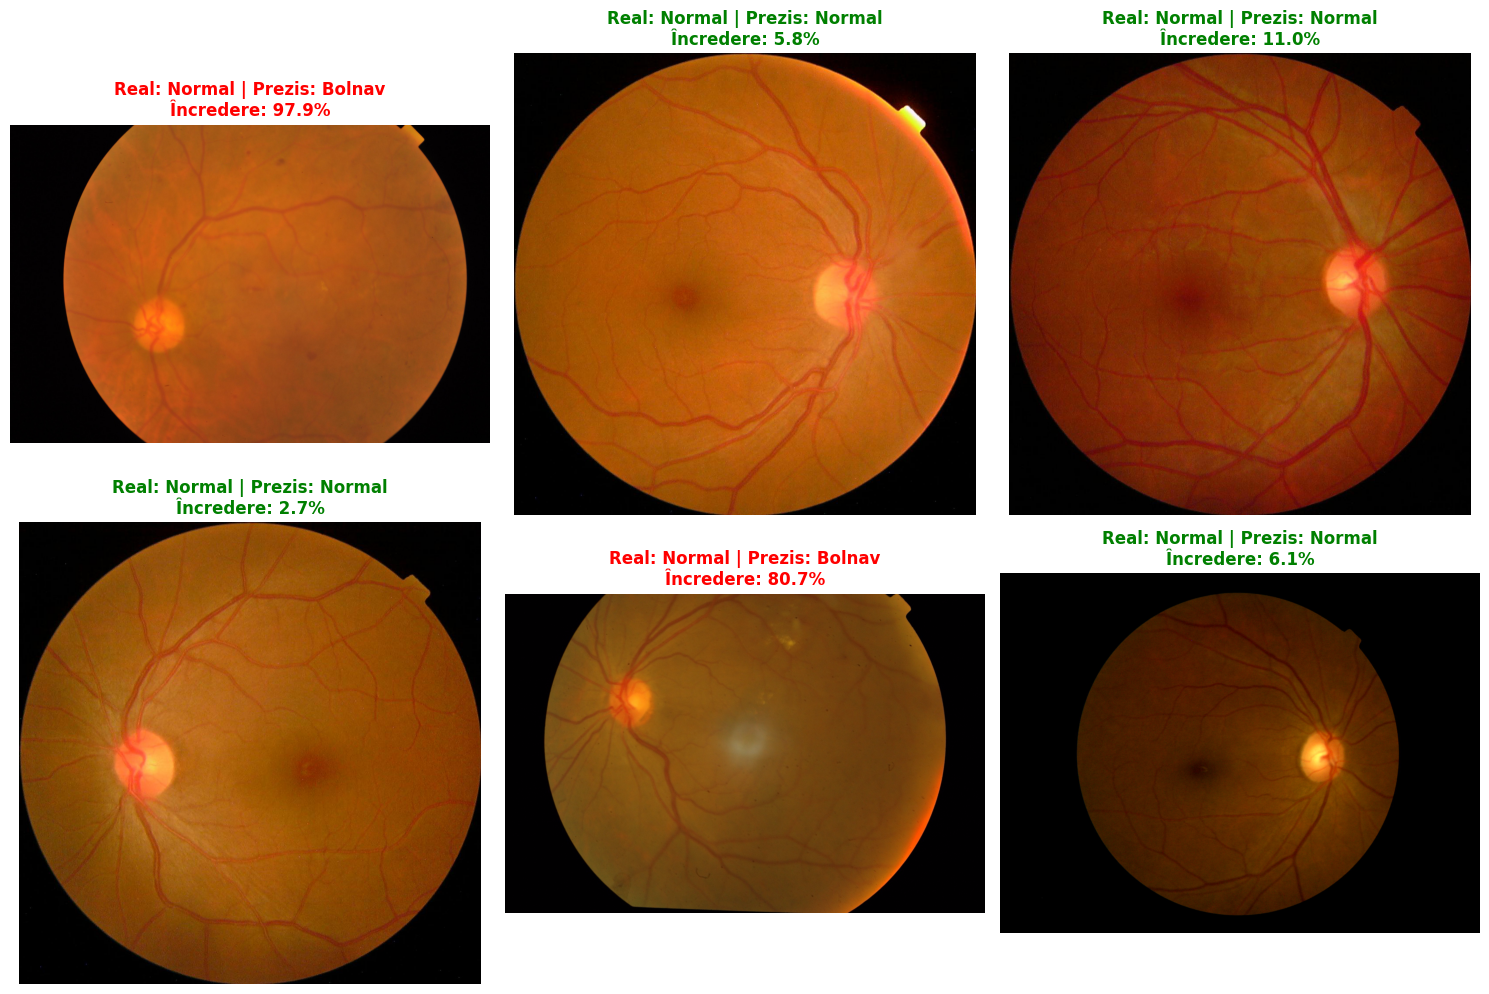

In [20]:
def vizualizare_predictii(model, device, test_csv_path, test_images_dir, num_imagini=6):
    """
    Alege aleatoriu un număr de imagini, face predicția și le afișează într-o grilă.
    """
    # 1. Încărcăm etichetele reale (Ground Truth)
    test_df = pd.read_csv(test_csv_path)
    
    # Alegem câteva rânduri la întâmplare
    sample_df = test_df.sample(n=num_imagini)
    
    # 2. Definim transformările pentru inferență
    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    model.eval()
    
    # 3. Pregătim figura pentru afișare (ex: 2 rânduri, 3 coloane pentru 6 imagini)
    fig = plt.figure(figsize=(15, 10))
    
    with torch.no_grad():
        for i, (index, row) in enumerate(sample_df.iterrows()):
            img_name = str(row.iloc[0])
            if not img_name.endswith('.png'):
                img_name += '.png'
                
            img_path = os.path.join(test_images_dir, img_name)
            adevarul_absolut = int(row.iloc[1]) # Ce a zis medicul (clasa reală)
            
            # Încărcăm imaginea originală pentru afișare vizuală
            try:
                image_pil = Image.open(img_path).convert('RGB')
            except FileNotFoundError:
                print(f"Imaginea {img_name} nu a fost găsită.")
                continue

            # Preprocesăm pentru model
            image_tensor = val_transforms(image_pil).unsqueeze(0).to(device)

            # Facem predicția
            raw_output = model(image_tensor)
            probability = torch.sigmoid(raw_output).item()
            predictie_model = 1 if probability >= 0.5 else 0
            
            # 4. Afișarea în grilă
            ax = fig.add_subplot(2, 3, i+1) # Ajustează dacă schimbi numărul de imagini
            ax.imshow(image_pil)
            ax.axis('off') # Ascundem axele (X, Y) ca să arate curat
            
            # Construim textul
            diagnostic_real = "Bolnav" if adevarul_absolut == 1 else "Normal"
            diagnostic_prezis = "Bolnav" if predictie_model == 1 else "Normal"
            
            titlu = f"Real: {diagnostic_real} | Prezis: {diagnostic_prezis}\nÎncredere: {probability*100:.1f}%"
            
            # Colorăm verde dacă e corect, roșu dacă a greșit
            culoare = "green" if adevarul_absolut == predictie_model else "red"
            ax.set_title(titlu, color=culoare, fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# ==========================================
# Apelarea funcției:
# ==========================================
vizualizare_predictii(model, device, "Dataset/test.csv", "Dataset/test_images/test_images", num_imagini=6)